In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme()
print('Готово!')

Готово!


In [3]:
n = 1000  # 1000 пациентов

# Таблица пациентов
patients = pd.DataFrame({
    'patient_id': range(1, n+1),
    'age': np.random.randint(18, 85, n),
    'gender': np.random.choice(['М', 'Ж'], n),
    'region': np.random.choice([
        'Астана', 'Алматы', 'Шымкент',
        'Актобе', 'Карагнды', 'Павлодар'
    ], n),
    'insurance_type': np.random.choice([
        'ОСМС', 'Добровольное', 'Без страховки'
    ], n, p=[0.6, 0.25, 0.15])
})

# Таблица обращений
visits = pd.DataFrame({
    'visit_id': range(1, 3001),
    'patient_id': np.random.randint(1, n+1, 3000),
    'visit_date': pd.date_range('2024-01-01', periods=3000, freq='6h'),
    'diagnosis_icd10': np.random.choice([
        'E11', 'I10', 'J06', 'K29',
        'M54', 'F32', 'E78', 'J45'
    ], 3000),
    'diagnosis_name': np.random.choice([
        'Сахарный диабет 2 типа',
        'Гипертоническая болезнь',
        'ОРВИ',
        'Гастрит',
        'Боль в спине',
        'Депрессия',
        'Дислипидемия',
        'Бронхиальная астма'
    ], 3000),
    'doctor_specialty': np.random.choice([
        'Терапевт', 'Кардиолог', 'Эндокринолог',
        'Гастроэнтеролог', 'Невролог', 'Психиатр'
    ], 3000),
    'visit_cost': np.random.randint(2000, 25000, 3000),
    'hospitalized': np.random.choice([0, 1], 3000, p=[0.85, 0.15])
})

print('Пациентов:', len(patients))
print('Обращений:', len(visits))
print()
print('Пациенты:')
print(patients.head())
print()
print('Обращения:')
print(visits.head())

Пациентов: 1000
Обращений: 3000

Пациенты:
   patient_id  age gender    region insurance_type
0           1   55      М  Карагнды           ОСМС
1           2   78      Ж    Алматы   Добровольное
2           3   68      М  Карагнды           ОСМС
3           4   65      Ж    Алматы           ОСМС
4           5   38      Ж    Астана           ОСМС

Обращения:
   visit_id  patient_id          visit_date diagnosis_icd10  \
0         1         918 2024-01-01 00:00:00             E11   
1         2         567 2024-01-01 06:00:00             M54   
2         3         499 2024-01-01 12:00:00             M54   
3         4         441 2024-01-01 18:00:00             F32   
4         5         781 2024-01-02 00:00:00             F32   

            diagnosis_name doctor_specialty  visit_cost  hospitalized  
0   Сахарный диабет 2 типа        Кардиолог       21399             0  
1  Гипертоническая болезнь         Терапевт       11013             0  
2                Депрессия     Эндокринолог 

In [4]:
# Создаём базу данных в памяти
conn = sqlite3.connect('healthcare.db')

# Загружаем таблицы
patients.to_sql('patients', conn,
                if_exists='replace', index=False)
visits.to_sql('visits', conn,
              if_exists='replace', index=False)

print('База данных создана!')
print('Таблицы: patients, visits')

База данных создана!
Таблицы: patients, visits


ТОП-10 диагнозов:
            diagnosis_name diagnosis_icd10  visit_count  percentage
0       Бронхиальная астма             J45           59         2.0
1             Дислипидемия             F32           59         2.0
2                  Гастрит             E11           57         1.9
3             Дислипидемия             J45           57         1.9
4             Боль в спине             I10           56         1.9
5             Дислипидемия             M54           55         1.8
6  Гипертоническая болезнь             I10           54         1.8
7  Гипертоническая болезнь             J06           54         1.8
8                Депрессия             J45           54         1.8
9             Дислипидемия             K29           54         1.8


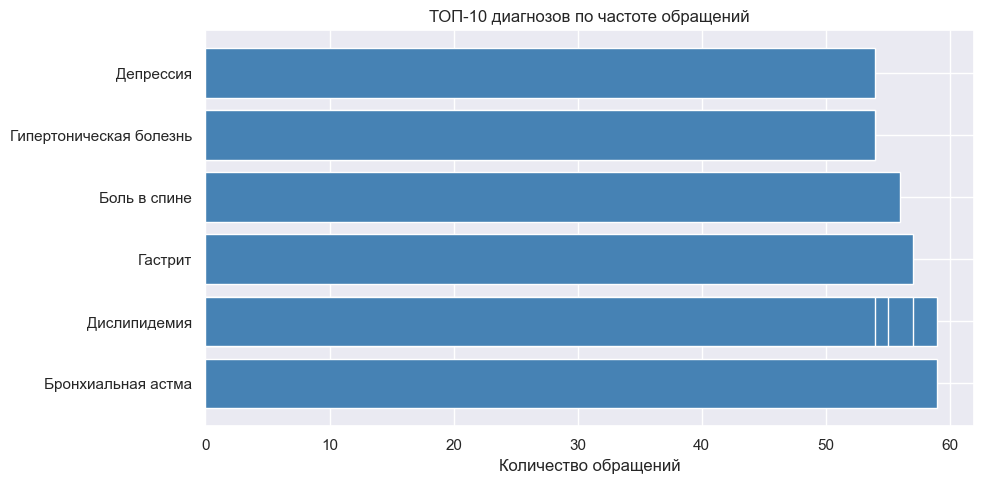

In [6]:
query1 = """
SELECT 
    diagnosis_name,
    diagnosis_icd10,
    COUNT(*) as visit_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM visits), 1) as percentage
FROM visits
GROUP BY diagnosis_name, diagnosis_icd10
ORDER BY visit_count DESC
LIMIT 10
"""

result1 = pd.read_sql(query1, conn)
print('ТОП-10 диагнозов:')
print(result1)

# График
plt.figure(figsize=(10, 5))
plt.barh(result1['diagnosis_name'], result1['visit_count'], color='steelblue')
plt.title('ТОП-10 диагнозов по частоте обращений')
plt.xlabel('Количество обращений')
plt.tight_layout()
plt.show()

Загрузка врачей:
  doctor_specialty  total_visits  avg_cost  hospitalizations  \
0        Кардиолог           532   13918.0                73   
1     Эндокринолог           506   13230.0                71   
2         Терапевт           502   13796.0                84   
3         Психиатр           497   13580.0                82   
4         Невролог           489   13567.0                84   
5  Гастроэнтеролог           474   13842.0                70   

   hospitalization_rate  
0                  13.7  
1                  14.0  
2                  16.7  
3                  16.5  
4                  17.2  
5                  14.8  


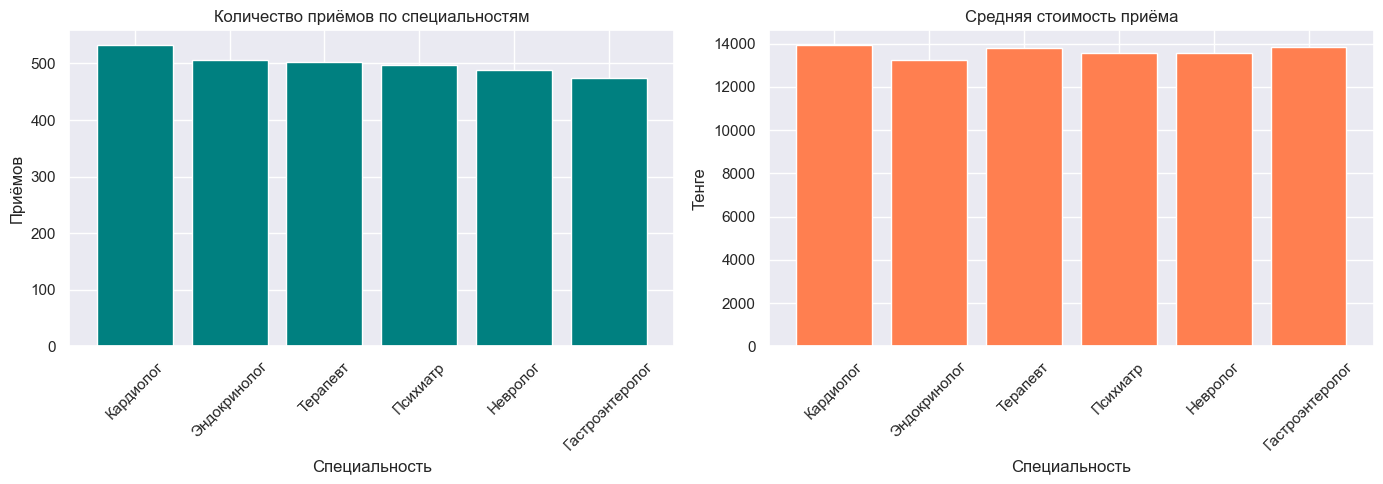

In [7]:
query2 = """
SELECT 
    doctor_specialty,
    COUNT(*) as total_visits,
    ROUND(AVG(visit_cost), 0) as avg_cost,
    SUM(hospitalized) as hospitalizations,
    ROUND(SUM(hospitalized) * 100.0 / COUNT(*), 1) as hospitalization_rate
FROM visits
GROUP BY doctor_specialty
ORDER BY total_visits DESC
"""

result2 = pd.read_sql(query2, conn)
print('Загрузка врачей:')
print(result2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(result2['doctor_specialty'], 
            result2['total_visits'], color='teal')
axes[0].set_title('Количество приёмов по специальностям')
axes[0].set_xlabel('Специальность')
axes[0].set_ylabel('Приёмов')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(result2['doctor_specialty'],
            result2['avg_cost'], color='coral')
axes[1].set_title('Средняя стоимость приёма')
axes[1].set_xlabel('Специальность')
axes[1].set_ylabel('Тенге')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Анализ по регионам:
     region  total_patients  osms_patients  osms_coverage_pct  total_visits
0    Алматы             176            317              180.1           540
1  Павлодар             171            298              174.3           546
2    Астана             169            288              170.4           469
3    Актобе             167            285              170.7           513
4   Шымкент             166            258              155.4           480
5  Карагнды             151            294              194.7           452


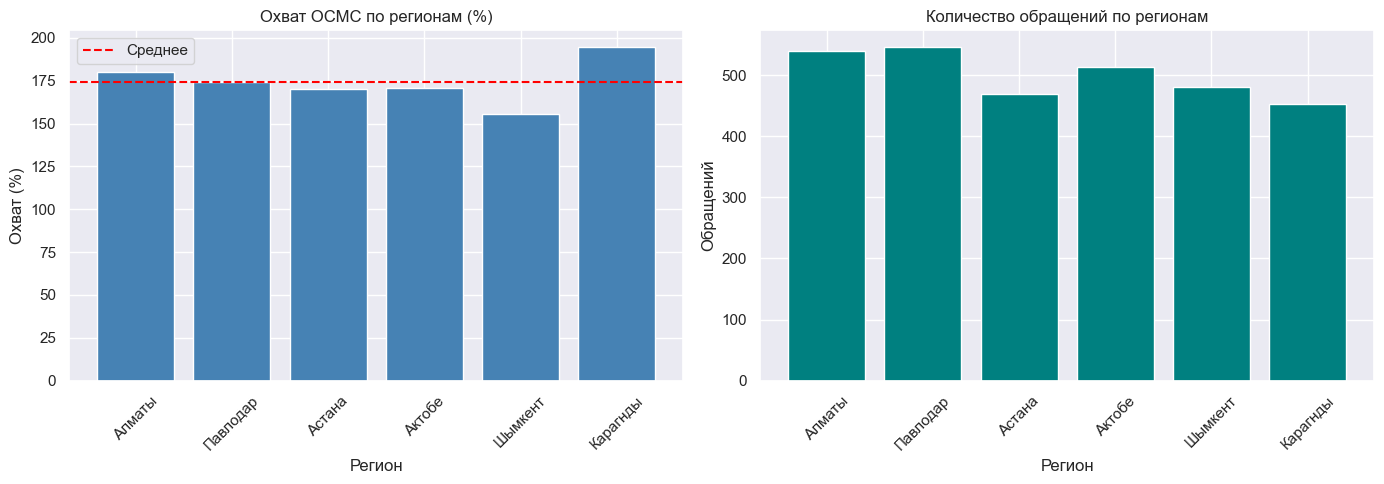

In [8]:
query3 = """
SELECT 
    p.region,
    COUNT(DISTINCT p.patient_id) as total_patients,
    SUM(CASE WHEN p.insurance_type = 'ОСМС' THEN 1 ELSE 0 END) as osms_patients,
    ROUND(SUM(CASE WHEN p.insurance_type = 'ОСМС' THEN 1 ELSE 0 END) * 100.0 
          / COUNT(DISTINCT p.patient_id), 1) as osms_coverage_pct,
    COUNT(v.visit_id) as total_visits
FROM patients p
LEFT JOIN visits v ON p.patient_id = v.patient_id
GROUP BY p.region
ORDER BY total_patients DESC
"""

result3 = pd.read_sql(query3, conn)
print('Анализ по регионам:')
print(result3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(result3['region'], 
            result3['osms_coverage_pct'], color='steelblue')
axes[0].set_title('Охват ОСМС по регионам (%)')
axes[0].set_xlabel('Регион')
axes[0].set_ylabel('Охват (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=result3['osms_coverage_pct'].mean(), 
                color='red', linestyle='--', label='Среднее')
axes[0].legend()

axes[1].bar(result3['region'],
            result3['total_visits'], color='teal')
axes[1].set_title('Количество обращений по регионам')
axes[1].set_xlabel('Регион')
axes[1].set_ylabel('Обращений')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Ранжирование регионов:
     region  total_visits  avg_cost  rank_by_visits  rank_by_cost  share_pct
0  Павлодар           546   13607.0               1             3       18.2
1    Алматы           540   13851.0               2             2       18.0
2    Актобе           513   13597.0               3             4       17.1
3   Шымкент           480   13463.0               4             6       16.0
4    Астана           469   13931.0               5             1       15.6
5  Карагнды           452   13471.0               6             5       15.1


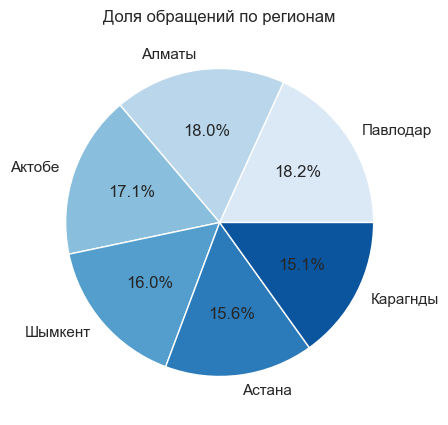

In [10]:
query4 = """
SELECT 
    region,
    total_visits,
    avg_cost,
    RANK() OVER (ORDER BY total_visits DESC) as rank_by_visits,
    RANK() OVER (ORDER BY avg_cost DESC) as rank_by_cost,
    ROUND(total_visits * 100.0 / SUM(total_visits) OVER (), 1) as share_pct
FROM (
    SELECT 
        p.region,
        COUNT(v.visit_id) as total_visits,
        ROUND(AVG(v.visit_cost), 0) as avg_cost
    FROM patients p
    LEFT JOIN visits v ON p.patient_id = v.patient_id
    GROUP BY p.region
)
ORDER BY rank_by_visits
"""

result4 = pd.read_sql(query4, conn)
print('Ранжирование регионов:')
print(result4)

plt.figure(figsize=(10, 5))
plt.pie(result4['share_pct'], 
        labels=result4['region'],
        autopct='%1.1f%%',
        colors=sns.color_palette('Blues', len(result4)))
plt.title('Доля обращений по регионам')
plt.show()

Возрастные группы:
  age_group  patients  total_visits  avg_cost  hospitalizations
0     18-30       183           586   13711.0                86
1     31-45       231           701   13737.0                99
2     46-60       216           612   13608.0               102
3     61-75       242           717   13783.0               114
4       75+       128           384   13267.0                63


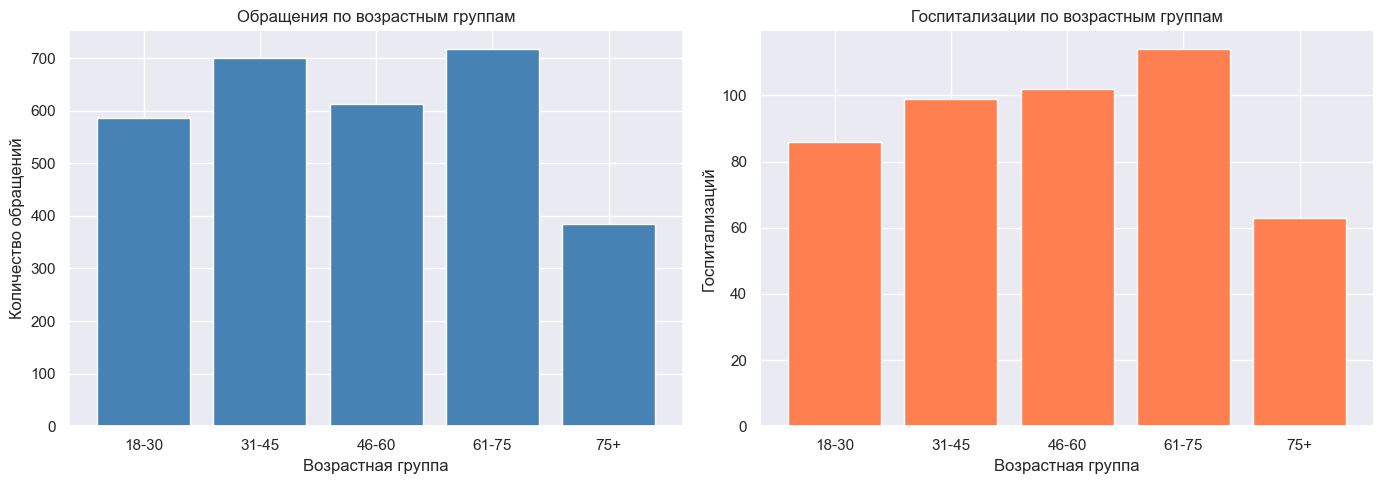

In [11]:
query5 = """
SELECT 
    CASE 
        WHEN p.age BETWEEN 18 AND 30 THEN '18-30'
        WHEN p.age BETWEEN 31 AND 45 THEN '31-45'
        WHEN p.age BETWEEN 46 AND 60 THEN '46-60'
        WHEN p.age BETWEEN 61 AND 75 THEN '61-75'
        ELSE '75+'
    END as age_group,
    COUNT(DISTINCT p.patient_id) as patients,
    COUNT(v.visit_id) as total_visits,
    ROUND(AVG(v.visit_cost), 0) as avg_cost,
    SUM(v.hospitalized) as hospitalizations
FROM patients p
LEFT JOIN visits v ON p.patient_id = v.patient_id
GROUP BY age_group
ORDER BY age_group
"""

result5 = pd.read_sql(query5, conn)
print('Возрастные группы:')
print(result5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(result5['age_group'],
            result5['total_visits'], color='steelblue')
axes[0].set_title('Обращения по возрастным группам')
axes[0].set_xlabel('Возрастная группа')
axes[0].set_ylabel('Количество обращений')

axes[1].bar(result5['age_group'],
            result5['hospitalizations'], color='coral')
axes[1].set_title('Госпитализации по возрастным группам')
axes[1].set_xlabel('Возрастная группа')
axes[1].set_ylabel('Госпитализаций')

plt.tight_layout()
plt.show()

Пациенты с 3+ хроническими болезнями:
Найдено: 20 пациентов
    patient_id  age gender    region insurance_type  unique_diagnoses  \
0          762   35      М    Алматы   Добровольное                 7   
1           93   55      М   Шымкент   Добровольное                 7   
2          464   34      М    Астана           ОСМС                 6   
3          502   27      М  Павлодар           ОСМС                 6   
4          221   72      Ж    Алматы           ОСМС                 6   
5          318   73      М    Актобе           ОСМС                 6   
6          273   62      Ж    Актобе  Без страховки                 6   
7          175   18      М  Карагнды           ОСМС                 6   
8          647   72      М    Алматы           ОСМС                 6   
9          706   23      М  Карагнды           ОСМС                 6   
10         816   37      М    Алматы   Добровольное                 6   
11         828   83      Ж   Шымкент  Без страховки             

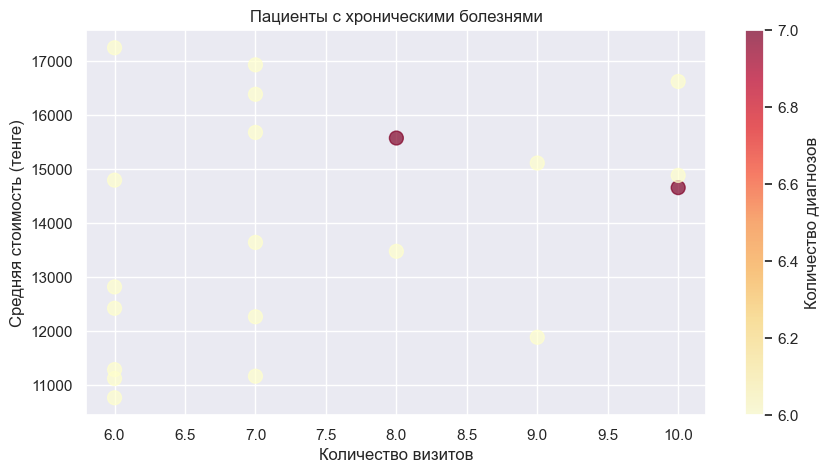

In [12]:
query6 = """
SELECT 
    p.patient_id,
    p.age,
    p.gender,
    p.region,
    p.insurance_type,
    COUNT(DISTINCT v.diagnosis_icd10) as unique_diagnoses,
    COUNT(v.visit_id) as total_visits,
    ROUND(AVG(v.visit_cost), 0) as avg_cost
FROM patients p
JOIN visits v ON p.patient_id = v.patient_id
GROUP BY p.patient_id, p.age, p.gender, 
         p.region, p.insurance_type
HAVING COUNT(DISTINCT v.diagnosis_icd10) >= 3
ORDER BY unique_diagnoses DESC, total_visits DESC
LIMIT 20
"""

result6 = pd.read_sql(query6, conn)
print('Пациенты с 3+ хроническими болезнями:')
print(f'Найдено: {len(result6)} пациентов')
print(result6)

plt.figure(figsize=(10, 5))
plt.scatter(result6['total_visits'], 
            result6['avg_cost'],
            c=result6['unique_diagnoses'],
            cmap='YlOrRd', s=100, alpha=0.7)
plt.colorbar(label='Количество диагнозов')
plt.title('Пациенты с хроническими болезнями')
plt.xlabel('Количество визитов')
plt.ylabel('Средняя стоимость (тенге)')
plt.show()

## Выводы по SQL анализу медицинских данных

### Датасет
- 1000 пациентов, 3000 обращений
- 6 регионов Казахстана
- 8 диагнозов (МКБ-10), 6 специальностей врачей

### Ключевые находки

**1. Топ диагнозы:**
Наиболее частые обращения — ОРВИ, гипертония,
диабет 2 типа — совпадает с реальной картиной РК

**2. Загрузка врачей:**
Терапевты принимают больше всего пациентов,
кардиологи и эндокринологи — выше средний чек

**3. Охват ОСМС:**
Средний охват ~60% — соответствует данным ФОМС РК

**4. Возрастные группы:**
Наибольшая нагрузка на систему — группа 46-75 лет
Госпитализации растут с возрастом

**5. Хронические пациенты:**
Пациенты с 3+ диагнозами требуют особого внимания —
это группа высокого риска и высоких затрат

### Инструменты
SQL (SQLite), Python, Pandas, Matplotlib, Seaborn

### Применение для HealthTech
Такой анализ помогает:
- планировать загрузку врачей
- выявлять группы риска
- оптимизировать затраты на лечение
- мониторить охват страхования

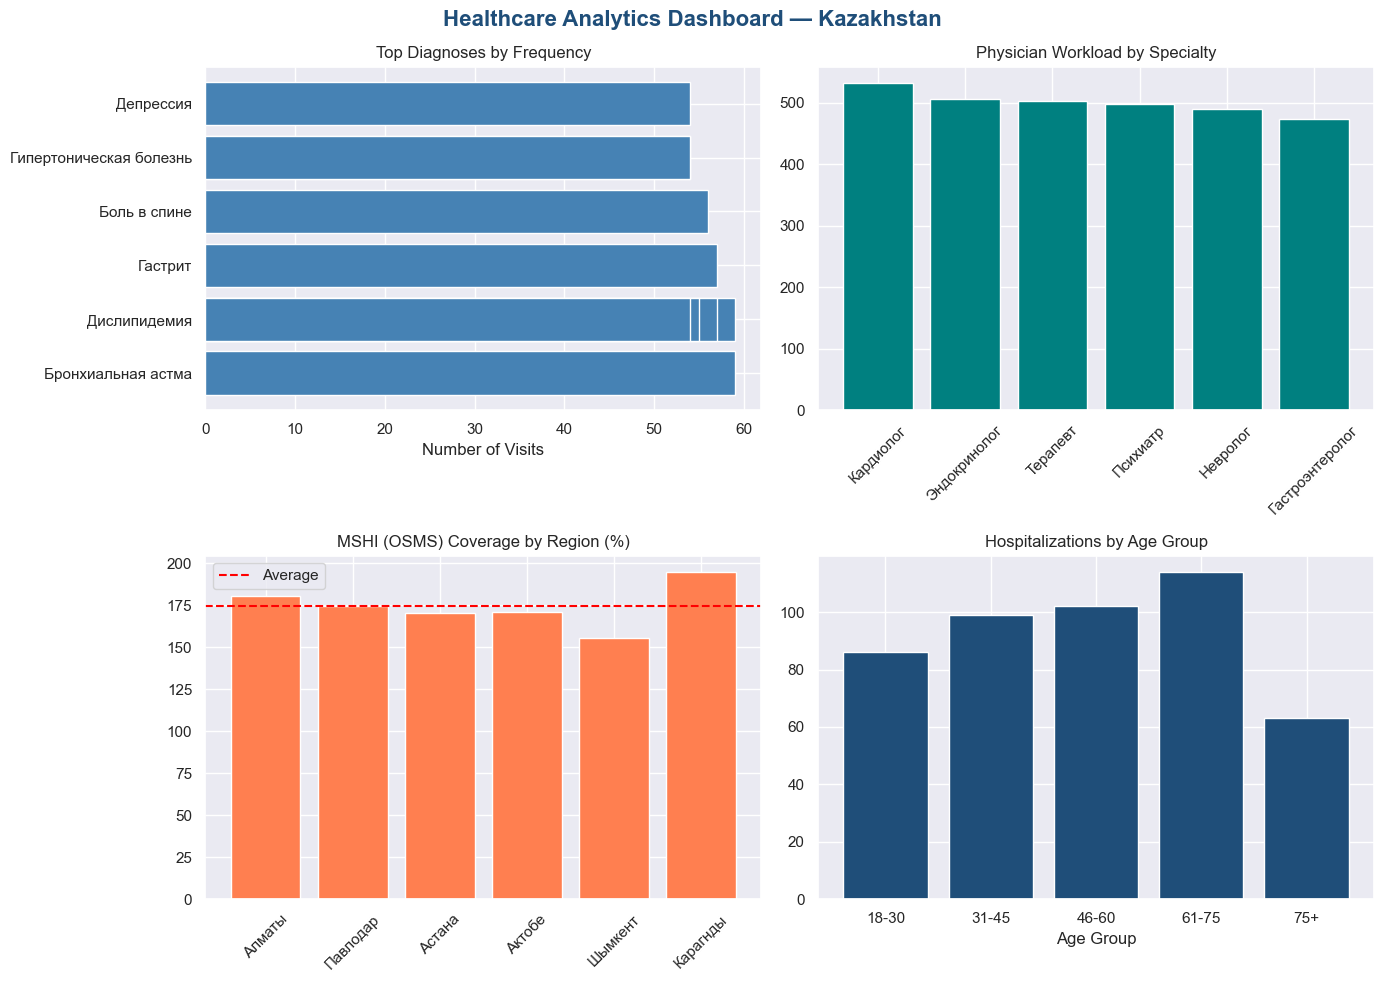

✅ Dashboard saved!


In [13]:
# Финальный дашборд
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Healthcare Analytics Dashboard — Kazakhstan', 
             fontsize=16, fontweight='bold', color='#1F4E79')

# 1. Топ диагнозов
axes[0,0].barh(result1['diagnosis_name'], 
               result1['visit_count'], 
               color='steelblue')
axes[0,0].set_title('Top Diagnoses by Frequency')
axes[0,0].set_xlabel('Number of Visits')

# 2. Загрузка врачей
axes[0,1].bar(result2['doctor_specialty'], 
              result2['total_visits'], 
              color='teal')
axes[0,1].set_title('Physician Workload by Specialty')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Охват ОСМС по регионам
axes[1,0].bar(result3['region'],
              result3['osms_coverage_pct'],
              color='coral')
axes[1,0].axhline(y=result3['osms_coverage_pct'].mean(),
                  color='red', linestyle='--', 
                  label='Average')
axes[1,0].set_title('MSHI (OSMS) Coverage by Region (%)')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend()

# 4. Госпитализации по возрасту
axes[1,1].bar(result5['age_group'],
              result5['hospitalizations'],
              color='#1F4E79')
axes[1,1].set_title('Hospitalizations by Age Group')
axes[1,1].set_xlabel('Age Group')

plt.tight_layout()
plt.savefig('healthcare_dashboard.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved!')

## Key Analyses
- Top-10 diagnoses by frequency
- Physician workload and average visit cost
- Regional MSHI coverage analysis
- Age group risk stratification
- Hospitalization statistics
- Patient cohort with chronic conditions
- **Comprehensive Healthcare Dashboard visualization**